Load the `tidymodels` and `ISLR2` package.

In [9]:
library('tidymodels')
library('ISLR2')

In this exercise we will explore the relationship of `hr` (hour of day) and `bikers` (number of bike rentals) from the `Bikeshare` data set (via the `ISLR2` package).

Plot `bikers` as a function of `hr` below.

In [ ]:
hr_means = Bikeshare |> group_by(hr) |> summarize(mean_bikers = mean(bikers))

ggplot(Bikeshare, aes(x = hr, y = bikers)) + 
    geom_point(alpha = 0.1) +
    geom_point(data = hr_means, aes(y = mean_bikers), color = 'steelblue', size = 3)

Let's build a model of `bikers` using `hr` as a predictor. We'll use a natural splines transformation and try a number of values for degrees of freedom to see which parameter value works best.

First let's create our data "folds" for evaluation.

Call your output table of folds "folds" and use the `vfold_cv` function to create the table. Create 10 folds.

In [ ]:
folds = vfold_cv(Bikeshare, v = 10)

folds |> glimpse()

Now we need a recipe that is "tunable."  Add a natural spline transformation step to your recipe and set `deg_free = tune()`.

In [ ]:
rec = recipe(bikers ~ hr, data = Bikeshare) |>
    step_ns(hr, deg_free = tune())

Let's test `deg_free` values from 3 to 15. The code below generates a table of `deg_free` values.

In [13]:
deg_free = tibble(deg_free = 3:15)

deg_free |> head()

deg_free
<int>
3
4
5
6
7
8


We can now create a model and run it over for each fold in `folds` and each value in the `deg_free` table.

Start by coding your model specification. Use `linear_reg`.

In [14]:
mod = linear_reg() |> set_engine('lm')



The `tune_grid` function fits your model for each fold/parameter combination in your parameters table. Run the code below to fit all the models.

In [15]:
mod_res = tune_grid(mod, rec, resamples = folds, grid = deg_free)

mod_res |> 
    collect_metrics() |>
    head()

deg_free,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
3,rmse,standard,0.06189152,10,0.002387892,Preprocessor01_Model1
3,rsq,standard,0.72102360,10,0.019228586,Preprocessor01_Model1
4,rmse,standard,0.06134803,10,0.002143052,Preprocessor02_Model1
4,rsq,standard,0.72704935,10,0.017091011,Preprocessor02_Model1
5,rmse,standard,0.06102022,10,0.002322657,Preprocessor03_Model1
5,rsq,standard,0.73033996,10,0.019449952,Preprocessor03_Model1


Now that you have seen the ouput of `collect_metrics` on all your models, Plot `deg_free` versus `mean` (the mean of the evaluation metric for all folds at a value for `deg_free`). Facet your chart by `.metric`.

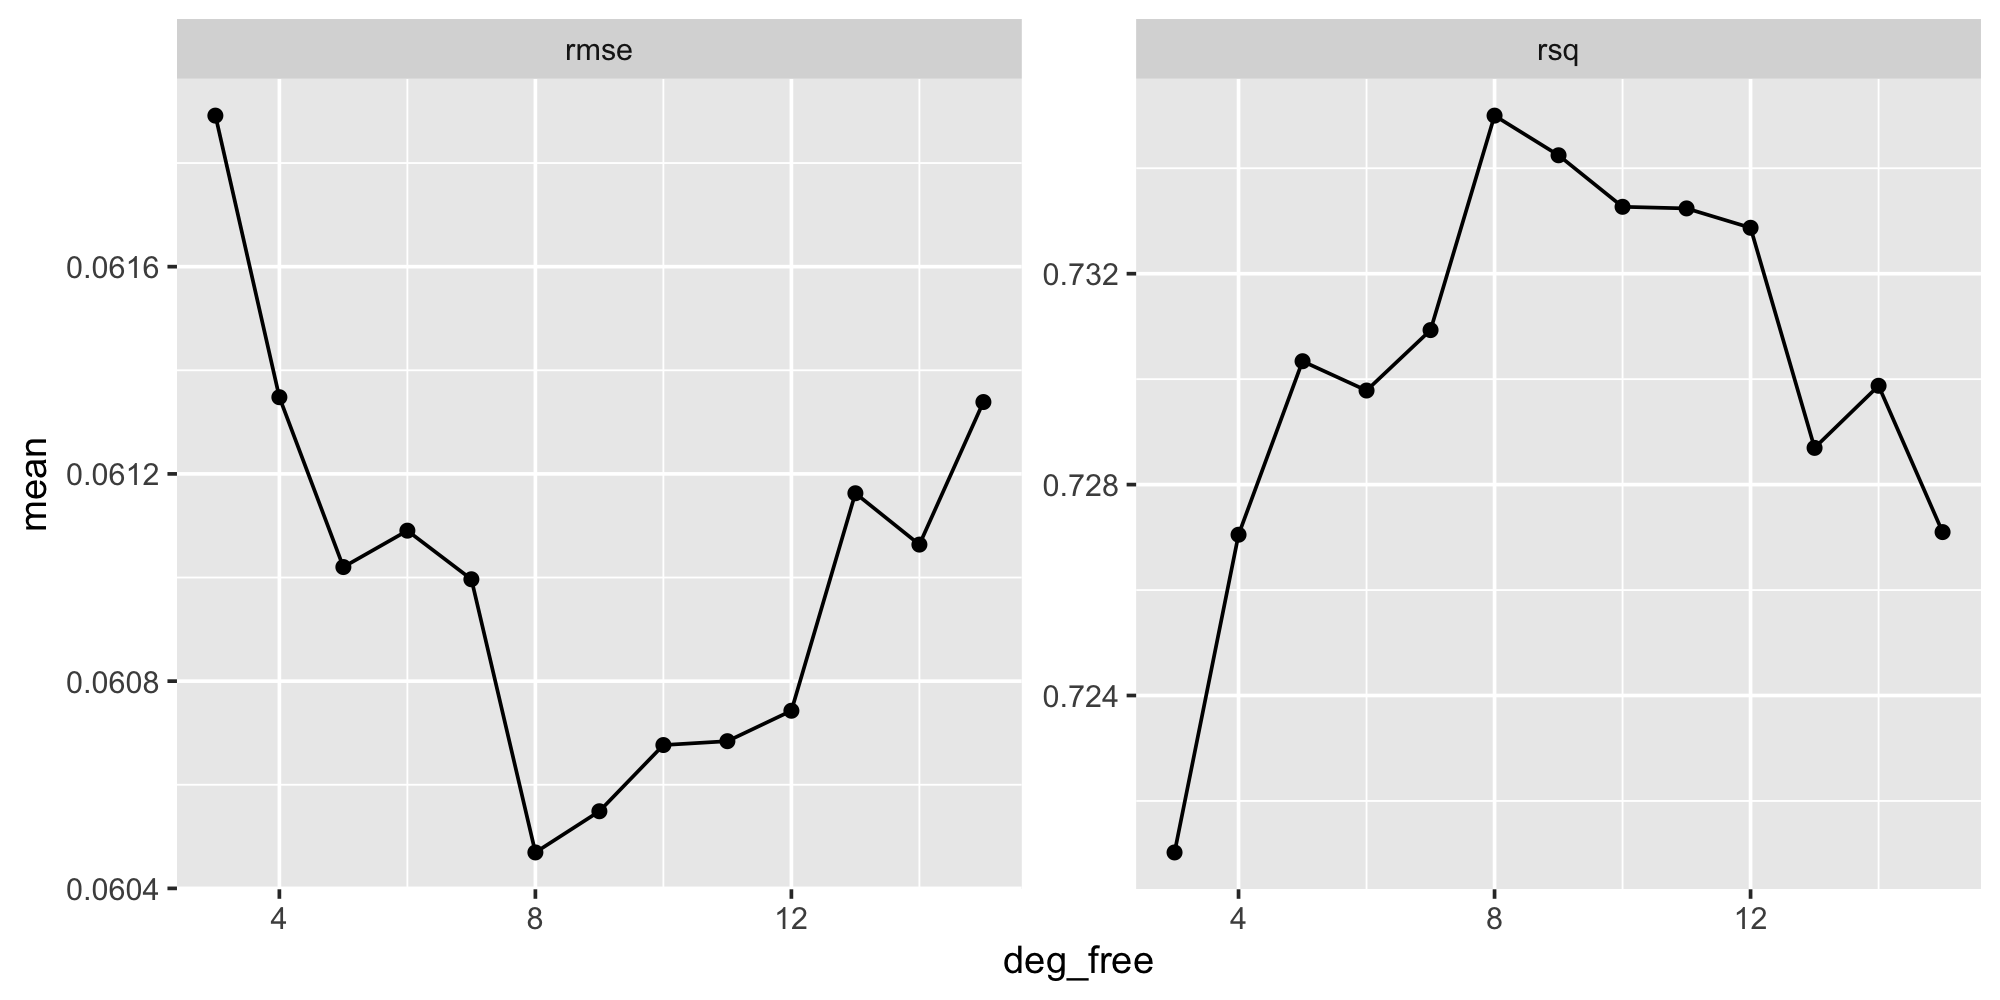

In [17]:
options(repr.plot.width = 8)

mod_res |> 
    collect_metrics() |>
ggplot(aes(x = deg_free, y = mean)) +
    geom_point() +
    geom_line() +
    facet_wrap(~.metric, ncol = 2, scales = 'free_y')

What appears to be the best value for `deg_free`? Create a model using this value and plot the model below.

In [ ]:
rec = recipe(bikers ~ hr, data = Bikeshare) |>
    step_ns(hr, deg_free = 8) |>
    prep()

mod_fit = mod |> fit(bikers ~ ., data = rec |> juice())

In [ ]:
mod_fit |> 
    predict(rec |> juice()) |> 
    bind_cols(Bikeshare) |>
ggplot(aes(x = hr, y = bikers)) + 
    geom_point(alpha = 0.1) +
    geom_point(data = hr_means, aes(y = mean_bikers), color = 'steelblue', size = 3) +
    geom_smooth(se = FALSE, method = lm, formula = y ~ splines::ns(x, df = 8))